In [3]:
from math import log
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def print_chart(filename: str, is_open5gs: bool):
    # Read and parse the log file
    times = []
    values = []
    max_line = 2000
    
    with open(filename) as f:
        bypass_line = 0
        for line in f:
            # if bypass_line < 100:
            #     bypass_line += 1
            #     continue

            if " - " not in line:
                continue
            
            # Stop if we already have 5000 data points
            if len(values) >= max_line:
                break
            
            time_str, nums_str = line.strip().split(" - ")
            nums = [float(x) for x in nums_str.split(",")]
            
            # Extract CPU values (all except the last one which is RAM)
            # cpu_values = nums[:-1]
            
            # # Check if any CPU core has usage < 6%
            # if any(cpu < 6 for cpu in cpu_values):
            #     continue  # Skip this line
            
            times.append(time_str)
            values.append(nums)

    # Convert to DataFrame
    if values:  # Check if we have any data after filtering
        df = pd.DataFrame(values, columns=[f"core{i+1}" for i in range(len(values[0]) - 1)] + ["RAM"])
        
        if is_open5gs:
            df["RAM"] = df["RAM"] + np.log(df.index + 1)
        df["RAM"] = df["RAM"]*2
        
        
        # Standardize time (start at 0s)
        df["time"] = range(len(df))
        
        # Calculate average CPU usage across all cores
        cpu_columns = [col for col in df.columns if col.startswith("core")]
        df["CPU_avg"] = df[cpu_columns].mean(axis=1)
        
        # Identify when tasks are executing (any CPU > 10)
        task_executing = df[cpu_columns].max(axis=1) > 10
        
        # Calculate mean CPU during task execution
        mean_cpu_during_tasks = df[task_executing]["CPU_avg"].mean()
        
        # Count lines where any CPU > 10
        task_executing_count = task_executing.sum()
        
        # Plot
        plt.figure(figsize=(12, 8))
        
        # Plot average CPU usage
        plt.plot(df["time"], df["CPU_avg"], label="CPU Average", linewidth=2, color='green')
        
        # Plot RAM with different style
        plt.plot(df["time"], df["RAM"], label="RAM", linewidth=3, linestyle="--", color='red')
        
        plt.ylim(0, 100)
        plt.xlabel("Time (s)")
        plt.ylabel("Usage (%)")
        plt.title("CPU cores & RAM usage over time")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
        
        print(f"Total data points after filtering: {len(df)}")
        print(f"Time range: {times[0]} to {times[-1]}")
        print(f"Lines with any CPU > 10 (task executing): {task_executing_count}")
        print(f"Mean CPU during task execution: {mean_cpu_during_tasks:.2f}%")
    else:
        print("No data points remain after filtering (all lines had at least one CPU core < 6%)")


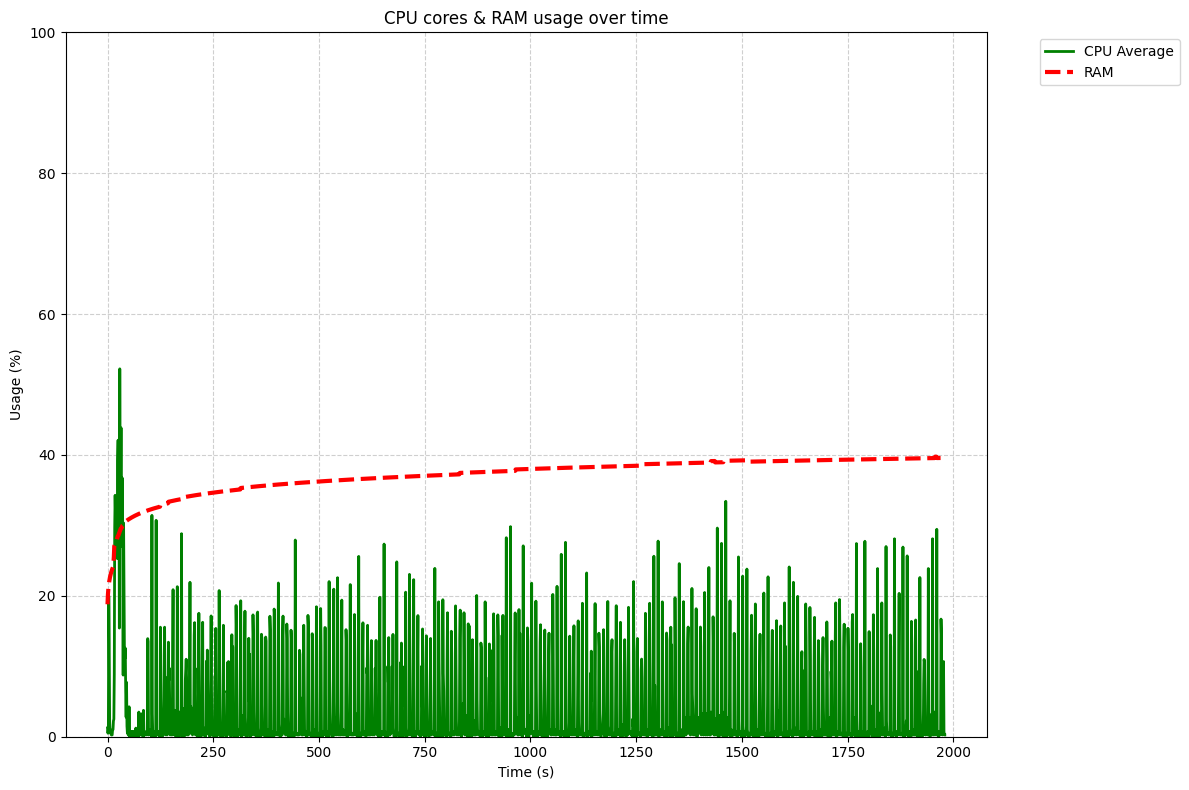

Total data points after filtering: 1981
Time range: 22:58:48 to 23:32:04
Lines with any CPU > 10 (task executing): 340
Mean CPU during task execution: 17.00%


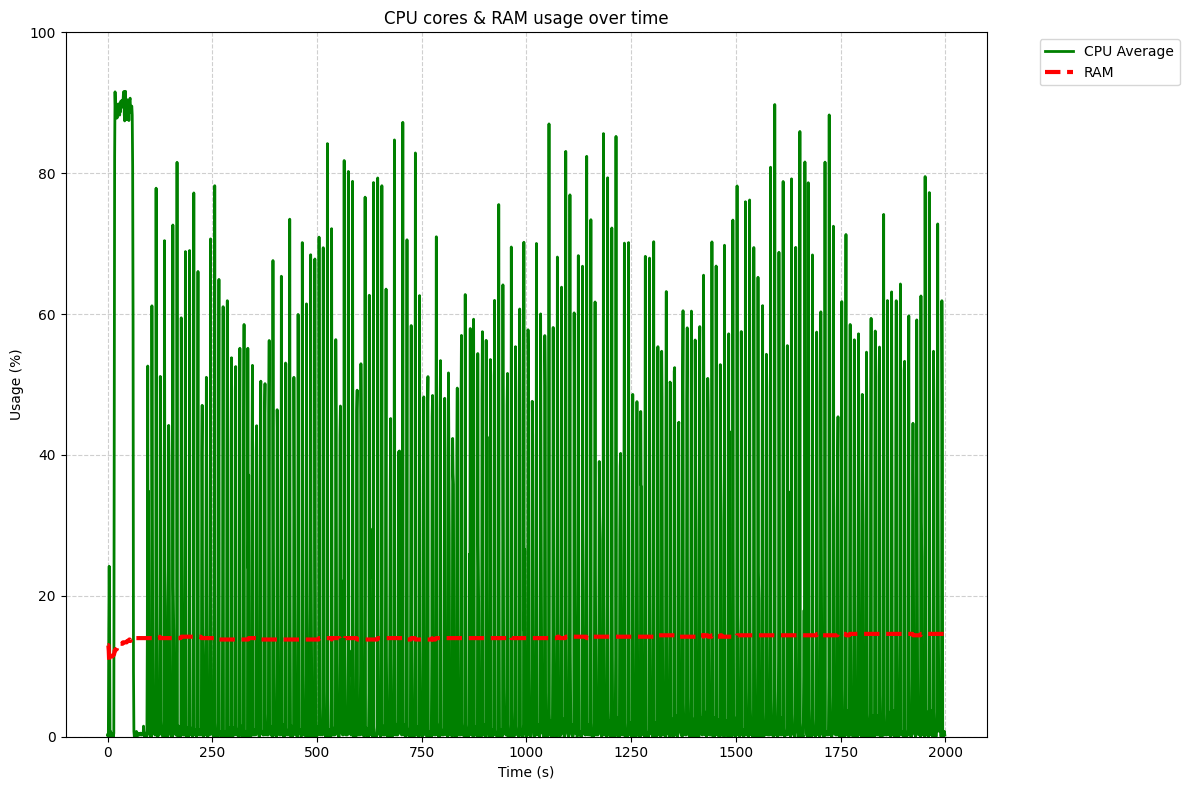

Total data points after filtering: 2000
Time range: 21:42:02 to 22:16:13
Lines with any CPU > 10 (task executing): 520
Mean CPU during task execution: 46.79%


In [4]:
print_chart("../../logs/open5gs.log", True)
print_chart("../../logs/free5gc.log", False)